In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
tau = 10.0      # ms
taus = 2.0      # ms
dt = 0.1        # ms
T = 200.0       # ms
steps = int(T / dt)

L = -70.0       # mV
EI = -80.0      # mV
Vth = -50.0     # mV
Vr = -60.0      # mV

In [2]:

def simulate_two_neurons(I1=40.0, I2=40.0, GE=0.1, GI=0.5, seed=None):
    rng = np.random.default_rng(seed)

    t = np.arange(steps + 1) * dt

    # memory potential and conductances for both neurons over time
    V = np.zeros((2, steps + 1))
    gE = np.zeros((2, steps + 1))
    gI = np.zeros((2, steps + 1))

    # set random initial voltages between L and Vr
    V[:, 0] = rng.uniform(L, Vr, size=2)

    # a list of 2 lists to store spike times for both neurons
    spike_times = [[], []]

    Iext = np.array([I1, I2], dtype=float)
    decay = np.exp(-dt / taus)

    for n in range(steps):
        # decay conductances at time step n
        ge = gE[:, n] * decay
        gi = gI[:, n] * decay

        # exponential Euler update for voltage
        A = L + Iext + gi * EI
        B = 1.0 + ge + gi
        Vinf = A / B
        Vnew = Vinf + (V[:, n] - Vinf) * np.exp(-B * dt / tau)

        # store decayed values for next time step
        gE[:, n+1] = ge
        gI[:, n+1] = gi
        V[:, n+1] = Vnew

        fired = Vnew >= Vth

        # neuron 0 spikes
        if fired[0]:
            spike_times[0].append(t[n+1])
            V[0, n] = 0
            V[0, n+1] = Vr
            gE[0, n+1] += GE      # self excitation
            gI[1, n+1] += GI      # inhibit neuron 1

        # neuron 1 spikes
        if fired[1]:
            spike_times[1].append(t[n+1])
            V[1, n] = 0
            V[1, n+1] = Vr
            gE[1, n+1] += GE      # self excitation
            gI[0, n+1] += GI      # inhibit neuron 0

    return t, V, gE, gI, spike_times

def firing_rate(spikes, T=200.0):
    return len(spikes) / (T / 1000.0)   # Hz

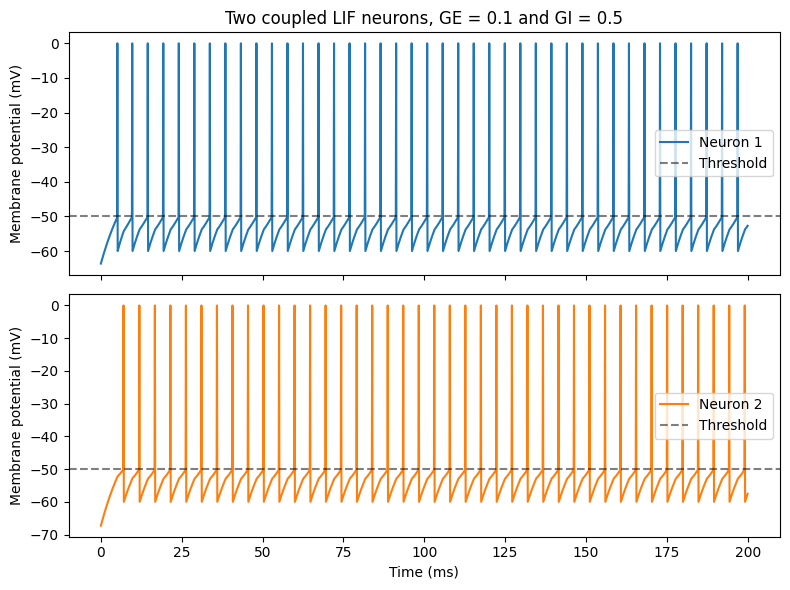

Neuron 1 spikes: 41 rate = 205.0 Hz
Neuron 2 spikes: 41 rate = 205.0 Hz


In [10]:
t, V, gE, gI, spikes = simulate_two_neurons(I1=40, I2=40, GE=0.1, GI=0.5, seed=0)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Top plot: Neuron 1
axes[0].plot(t, V[0], label='Neuron 1', color='C0')
axes[0].axhline(Vth, ls='--', c='k', alpha=0.5, label='Threshold')
axes[0].set_ylabel('Membrane potential (mV)')
axes[0].set_title('Two coupled LIF neurons, GE = 0.1 and GI = 0.5')
axes[0].legend()

# Bottom plot: Neuron 2
axes[1].plot(t, V[1], label='Neuron 2', color='C1')
axes[1].axhline(Vth, ls='--', c='k', alpha=0.5, label='Threshold')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Membrane potential (mV)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Neuron 1 spikes:", len(spikes[0]), "rate =", firing_rate(spikes[0]), "Hz")
print("Neuron 2 spikes:", len(spikes[1]), "rate =", firing_rate(spikes[1]), "Hz")

Find a GI giving WTA

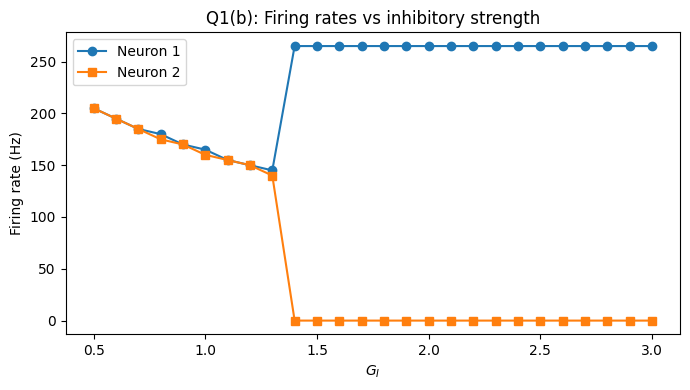

In [17]:
GI_values = np.arange(0.5, 3.01, 0.1)

rates1 = []
rates2 = []

# fixed seed so initial condition is consistent across GI
for GI in GI_values:
    t, V, gE, gI, spikes = simulate_two_neurons(I1=40, I2=40, GE=0.1, GI=GI, seed=0)
    rates1.append(firing_rate(spikes[0]))
    rates2.append(firing_rate(spikes[1]))

plt.figure(figsize=(7,4))
plt.plot(GI_values, rates1, 'o-', label='Neuron 1')
plt.plot(GI_values, rates2, 's-', label='Neuron 2')
plt.xlabel(r'$G_I$')
plt.ylabel('Firing rate (Hz)')
plt.title('Q1(b): Firing rates vs inhibitory strength')
plt.legend()
plt.tight_layout()
plt.show()

In WTA, one neuron fires all the time and one neuron fires 0. Here we find that the at GI = 1.4 the network becomes WTA

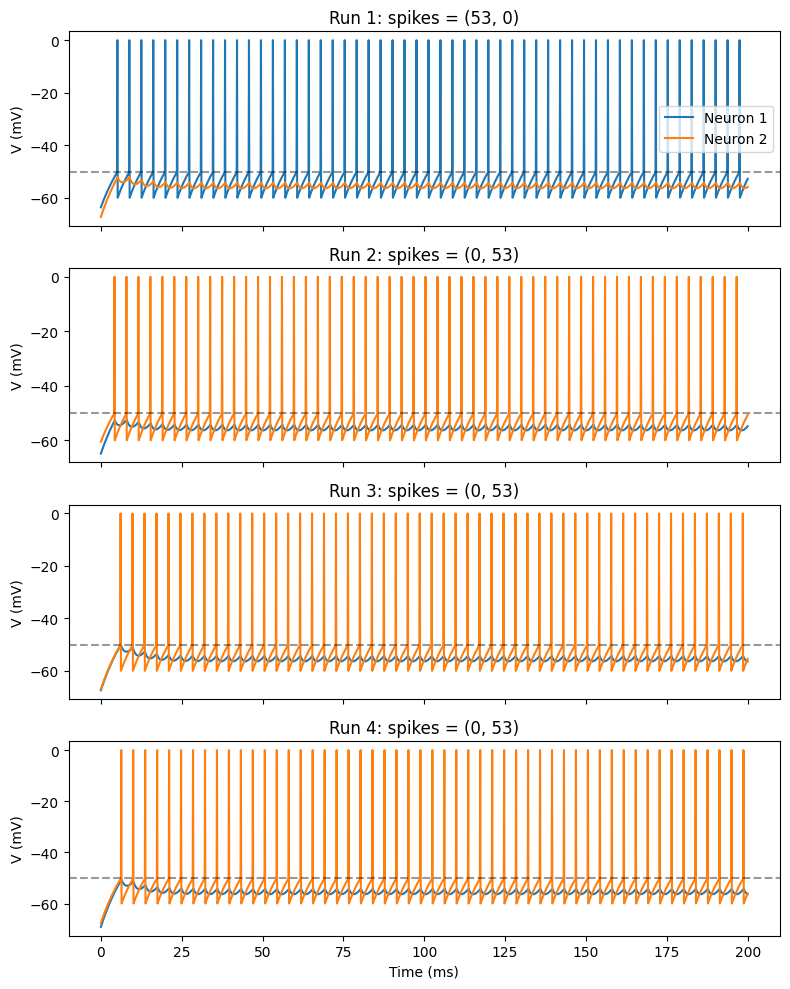

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

for k in range(4):
    t, V, gE, gI, spikes = simulate_two_neurons(I1=40, I2=40, GE=0.1, GI=2.0, seed=k)
    axes[k].plot(t, V[0], label='Neuron 1')
    axes[k].plot(t, V[1], label='Neuron 2')
    axes[k].axhline(Vth, ls='--', c='k', alpha=0.4)
    axes[k].set_ylabel('V (mV)')
    axes[k].set_title(
        f'Run {k+1}: spikes = ({len(spikes[0])}, {len(spikes[1])})'
    )

axes[-1].set_xlabel('Time (ms)')
axes[0].legend()
plt.tight_layout()
plt.show()